# Starting kit 

In [1]:
import sys

sys.path.append('/rds/rds-clecat/generative_modelling/STL_26')

from STL_main.STL_2D_FFT_Torch import STL_2D_FFT_Torch as DataClass
from STL_main.ST_Operator import ST_Operator as SO
from STL_main.Synthesis import optimize_scattering_LBFGS

In [2]:
import os
import sys

path_STL= os.path.join(os.getcwd(), 'STL_26')

sys.path.append(path_STL)

In [3]:
import scipy.stats as stats
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.fft
from importlib import reload
from functools import partial
import sys
import healpy as hp
import os

In [4]:
torch.cuda.is_available()

True

In [5]:
import glob
import numpy as np

files = glob.glob("tSZ_10_patches_256/superpatch_00/*.npy")
patches = [np.load(f) for f in files]

print(f"{len(patches)} maps loaded")

# The maps need to be in float 64
for i in range(len(patches)):
    patches[i] = patches[i].astype(np.float64)

10 maps loaded


Visualize a patch

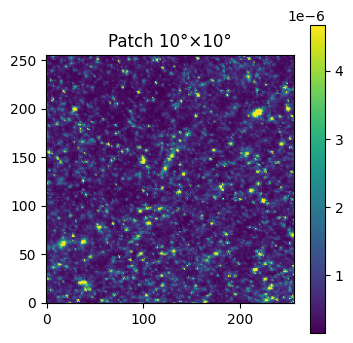

In [6]:
vmin, vmax = np.percentile(patches[0], [1, 99]) #colorbar

plt.figure(figsize=(4, 4))
im = plt.imshow(patches[0], vmin=vmin, vmax=vmax, origin='lower')
plt.colorbar(im)
plt.title("Patch 10°×10°")
plt.show()

Normalize the patch to improve the synthesis

In [7]:
patch = (patches[0] - np.mean(patches[0]))/np.std(patches[0])

Synthesis parameters

In [8]:
target = patch
seed=10
target = DataClass(target, pbc=False) #embed the target into a format suitable to do the synthesis
st_op = target.get_ST_op() #if there is more than one channel in the synthesis (not the case here)    

compute_cross_matrix = None

Launch the synthesis (you can tune the hyperparameters)

In [9]:
u1, histo1 = optimize_scattering_LBFGS(
        target=target,
        st_op_target=st_op,
        st_op_running=st_op,
        pbc_running=True, #to take into account the periodic boundary conditions
        compute_cross_matrix=compute_cross_matrix,    #if there is more than one channel in the synthesis (not the case here)    
        nbatch=1, #number of patches synthetized
        max_iter=200, #maximum number of iterations in the optimization loop (never use more than max_iter = 500, it will increase the cost by an enormous factor while not improving the results) 
        lr=1, #learning rate
        history_size=50, #number of steps that are kept in memory during the optimization
        print_iter=10, # safety prints that display the value of the loss
        verbose=True,
        seed=seed, #for reproducibility 
    )

Running synthesis on device cuda:0 dtype torch.float64
Initial shape for u: (1, 1, 256, 256)
Warning! Data with shape (16, 16) too small to be cropped with border 9. Using border=7 instead.
Synthesis on 3970 ST coefficients
[LBFGS] inner iter 10, loss = 7.538708e+00
[LBFGS] inner iter 20, loss = 2.506205e+00
[LBFGS] inner iter 30, loss = 5.745143e-01
[LBFGS] inner iter 40, loss = 1.810790e-01
[LBFGS] inner iter 50, loss = 1.007762e-01
[LBFGS] inner iter 60, loss = 7.406461e-02
[LBFGS] inner iter 70, loss = 5.891808e-02
[LBFGS] inner iter 80, loss = 4.854159e-02
[LBFGS] inner iter 90, loss = 4.149283e-02
[LBFGS] inner iter 100, loss = 3.694661e-02
[LBFGS] inner iter 110, loss = 3.346265e-02
[LBFGS] inner iter 120, loss = 3.106357e-02
[LBFGS] inner iter 130, loss = 2.930120e-02
[LBFGS] inner iter 140, loss = 2.805069e-02
[LBFGS] inner iter 150, loss = 2.689792e-02
[LBFGS] inner iter 160, loss = 2.582319e-02
[LBFGS] inner iter 170, loss = 2.509717e-02
[LBFGS] inner iter 180, loss = 2.4342

Plot the patch synthetized and the target

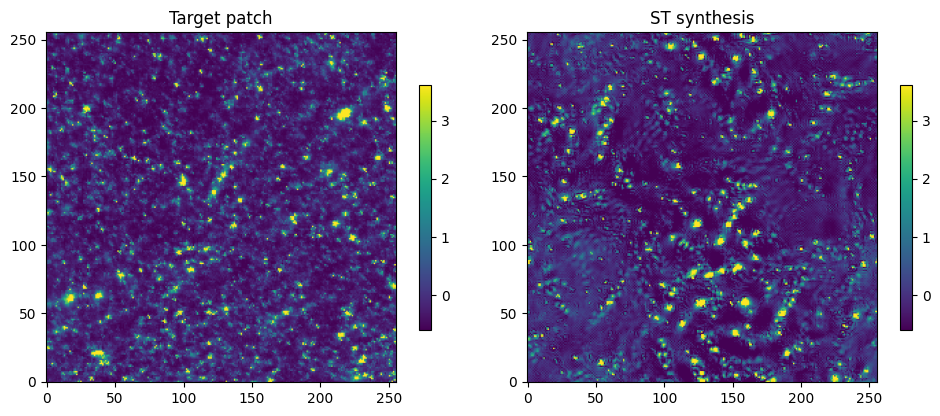

1.4069476385486848e-05
0.9999505098127032
1.070523292102354e-06


In [10]:
plt.figure(figsize=(10,4))
#vmin, vmax = np.nanpercentile(patches[0], [1, 99])
#vmin, vmax = np.nanpercentile(u1.cpu().numpy(), [1, 99])
vmin, vmax = np.nanpercentile(patch, [1, 99])

plt.subplot(1,2,1)
plt.imshow(patch - np.mean(patch), origin="lower", vmin=vmin, vmax=vmax)
plt.colorbar(shrink=0.7)
plt.title("Target patch")

plt.subplot(1,2,2)
plt.imshow(u1.cpu().numpy() - np.mean(u1.cpu().numpy()), origin="lower", vmin=vmin, vmax=vmax)
plt.colorbar(shrink=0.7)
plt.title("ST synthesis")

plt.tight_layout()
plt.show()

print(np.mean(u1.cpu().numpy()))
print(np.std(u1.cpu().numpy()))
print(np.std(patches[0]))

# Log space synthesis 

Lognormalization

In [11]:
#Load the patches 
from scipy.optimize import minimize
from scipy.stats import skew, kurtosis


def load_patches_log(obj):
    """
    Returns np.ndarray of shape (H,W) or (N,H,W)
    """
    if isinstance(obj, np.ndarray):
        return np.asarray(obj)

    if isinstance(obj, str):
        if os.path.isdir(obj):
            patches = []
            for f in sorted(os.listdir(obj)):
                if f.endswith(".npy"):
                    patches.append(np.load(os.path.join(obj, f)))
            if len(patches) == 0:
                raise ValueError(f"No .npy files found in folder: {obj}")
            return np.stack(patches)

        if obj.endswith(".npy"):
            return np.load(obj)

        if obj.endswith(".npz"):
            z = np.load(obj)
            if "patches" not in z:
                raise ValueError(f"{obj} does not contain key 'patches'")
            return z["patches"]

    raise ValueError("Unsupported input type (need ndarray, .npy, .npz, or folder)")
    
#Find the parameters to do the transformation 

def log_transform(x, A, B, eps=1e-9):
    return np.log(A * x + B + eps)


def objective(params, data_flat):
    A, B = params

    if A <= 0:
        return 1e20
    if np.any(A * data_flat + B <= 0):
        return 1e20

    y = log_transform(data_flat, A, B, eps=1e-9)
    return skew(y) ** 2 + kurtosis(y) ** 2 #goal function = skew + kurtosis in order to get a more gaussian historgram


def find_parameters(obj, margin=1.0, method="Nelder-Mead", max_iter=3000, verbose=False):
    """
    obj : ndarray (H,W) or (N,H,W) OR path to .npy/.npz OR folder of .npy
    Returns : A (float), B (float) (globaux)
    """
    patches = load_patches_log(obj).astype(np.float64)

    if patches.ndim == 2:
        data_flat = patches.reshape(-1)
    elif patches.ndim == 3:
        data_flat = patches.reshape(-1)
    else:
        raise ValueError("patches must be (H,W) or (N,H,W)")

    A_init = 1.0
    minx = float(np.min(data_flat))
    B_init = (-A_init * minx) + margin
    if B_init <= 0:
        B_init = margin

    res = minimize(
        objective,
        x0=np.array([A_init, B_init], dtype=np.float64),
        args=(data_flat,),
        method=method,
        options={"maxiter": max_iter, "disp": verbose},
    )

    A_opt, B_opt = map(float, res.x)
    if not res.success:
        raise RuntimeError(f"Optimization failed: {res.message}")
    if A_opt <= 0:
        raise RuntimeError(f"Invalid A found: A={A_opt} (must be > 0)")
    if np.any(A_opt * data_flat + B_opt <= 0):
        raise RuntimeError(
            "Invalid (A,B): Ax+B <= 0 for some pixels. "
            f"Got A={A_opt}, B={B_opt}. Try increasing margin or changing init/method."
        )

    return A_opt, B_opt

# compute the result patches
def normalize_array(patches, A, B, eps=1e-6):
    """
    y = log(Ax+B+eps), then standardisation (mean/std)
    Mean/std computed globally (on the whole tensor)
    """
    patches = np.asarray(patches, dtype=np.float64)

    if np.any(A * patches + B <= 0):
        raise ValueError("Ax+B must be > 0 everywhere for log-transform.")

    y = np.log(A * patches + B + eps)

    mean = float(y.mean())
    std = float(y.std())
    if std == 0:
        raise ValueError("Std is zero after log-transform; check data / (A,B).")

    y_norm = (y - mean) / std
    return y_norm, mean, std


def denormalize_array(patches_norm, mean, std, A, B, eps=1e-6):
    """
    Inversion:
      y = norm*std + mean
      Ax+B+eps = exp(y)
      x = (exp(y) - eps - B) / A
    """
    patches_norm = np.asarray(patches_norm, dtype=np.float64)
    y = patches_norm * std + mean
    x = (np.exp(y) - eps - B) / A
    return x



# log normalization

def normalize(patch_or_path, eps=1e-6, save_to=None, **find_kwargs):
    patches = load_patches_log(patch_or_path)
    A, B = find_parameters(patches, **find_kwargs)
    patches_norm, mean, std = normalize_array(patches, A, B, eps=eps)

    if save_to is not None:
        if not str(save_to).endswith(".npz"):
            raise ValueError("save_to must be a .npz file path")
        np.savez(save_to, patches=patches_norm, mean=mean, std=std, A=A, B=B)

    return patches_norm, mean, std, A, B


def denormalize(patch_or_path, mean, std, A, B, eps=1e-6, save_to=None):
    patches_norm = load_patches_log(patch_or_path)
    patches = denormalize_array(patches_norm, mean, std, A, B, eps=eps)

    if save_to is not None:
        if not str(save_to).endswith(".npz"):
            raise ValueError("save_to must be a .npz file path")
        np.savez(save_to, patches=patches, mean=mean, std=std, A=A, B=B)

    return patches

Define the parameters of the synthesis

In [12]:
patch_log, mean, std, A, B = normalize(patch)

In [13]:
target = patch_log
seed=2
target = DataClass(target, pbc=False)
st_op = target.get_ST_op()

compute_cross_matrix = None

Synthesis in the log space

In [14]:
u1, histo1 = optimize_scattering_LBFGS(
        target=target,
        st_op_target=st_op,
        st_op_running=st_op,
        pbc_running=True,
        compute_cross_matrix=compute_cross_matrix,        
        nbatch=1,
        max_iter=200,
        lr=1,
        history_size=50,
        print_iter=10,
        verbose=True,
        seed=seed,
    )

Running synthesis on device cuda:0 dtype torch.float64
Initial shape for u: (1, 1, 256, 256)
Warning! Data with shape (16, 16) too small to be cropped with border 9. Using border=7 instead.
Synthesis on 3970 ST coefficients
[LBFGS] inner iter 10, loss = 5.798926e+00
[LBFGS] inner iter 20, loss = 2.218496e-01
[LBFGS] inner iter 30, loss = 7.754015e-02
[LBFGS] inner iter 40, loss = 5.069828e-02
[LBFGS] inner iter 50, loss = 3.881019e-02
[LBFGS] inner iter 60, loss = 3.143128e-02
[LBFGS] inner iter 70, loss = 2.635678e-02
[LBFGS] inner iter 80, loss = 2.313969e-02
[LBFGS] inner iter 90, loss = 2.074985e-02
[LBFGS] inner iter 100, loss = 1.899594e-02
[LBFGS] inner iter 110, loss = 1.780501e-02
[LBFGS] inner iter 120, loss = 1.677528e-02
[LBFGS] inner iter 130, loss = 1.607153e-02
[LBFGS] inner iter 140, loss = 1.546926e-02
[LBFGS] inner iter 150, loss = 1.489910e-02
[LBFGS] inner iter 160, loss = 1.441751e-02
[LBFGS] inner iter 170, loss = 1.395333e-02
[LBFGS] inner iter 180, loss = 1.3578

Denormalize the patch synthetize to get the raw version

In [15]:
synth_raw = denormalize(u1.cpu().numpy(), mean, std, A, B)

Plot the patches

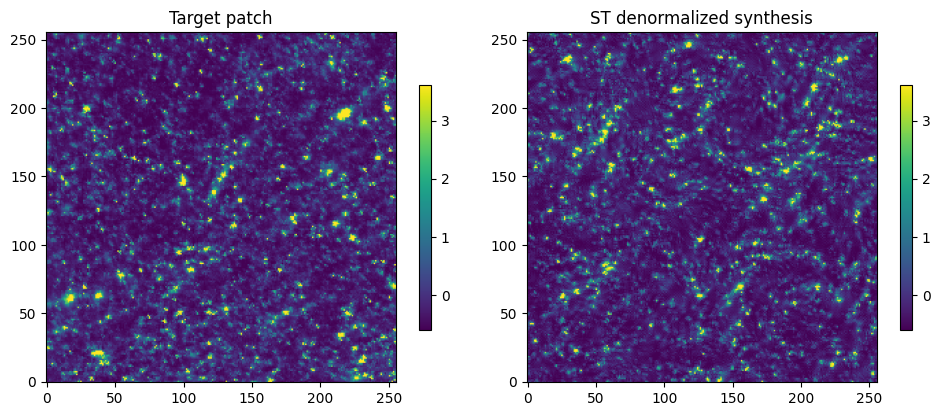

1.891445965042718e-05
1.000704610968851
1.0


In [16]:
plt.figure(figsize=(10,4))
vmin, vmax = np.nanpercentile(patch, [1, 99])

plt.subplot(1,2,1)
plt.imshow(patch, origin="lower", vmin=vmin, vmax=vmax)
plt.colorbar(shrink=0.7)
plt.title("Target patch")

plt.subplot(1,2,2)
plt.imshow(synth_raw, origin="lower", vmin=vmin, vmax=vmax)
plt.colorbar(shrink=0.7)
plt.title("ST denormalized synthesis")

plt.tight_layout()
plt.show()

print(np.mean(u1.cpu().numpy()))
print(np.std(u1.cpu().numpy()))
print(np.std(patch))

# Analysis 

Save the patches synthetized

In [17]:
import os

os.makedirs("data/target", exist_ok=True)
os.makedirs("data/synth", exist_ok=True)


np.save("data/target/patch_0.npy", patch)
np.save("data/synth/synth_0.npy", synth_raw)

configs = [
    {'path': "data/target", 'color': 'black', 'label': 'Original Target'},
    {'path': "data/synth", 'color': 'red', 'label': 'ST Synthesis'}
]

Here are some functions that compute the statistics on the patches you synthetized. You can use them to assess and improve the quality of your synthesis 

In [18]:
import os
import glob
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from quantimpy import minkowski as mk

#STATS

def power_spectrum(image):
    n = image.shape[0]
    fourier = np.fft.fftn(image)
    amplitude = (np.abs(fourier) ** 2).flatten()
    kfreq = np.fft.fftfreq(n) * n
    kfreq2D = np.meshgrid(kfreq, kfreq)
    knrm = (kfreq2D[0] ** 2 + kfreq2D[1] ** 2).flatten() ** (1 / 2)
    kbins = np.arange(1/2, n // 2 + 1, 1)
    kvals = (kbins[1:] + kbins[:-1]) / 2
    bins, _, _ = stats.binned_statistic(knrm, amplitude, statistic="mean", bins=kbins)
    return kvals, bins

def compute_minkowski(images, thresholds):
    res = {"areas": [], "lengths": [], "eulers": []}
    for image in images:
        a, l, e = [], [], []
        img_arr = np.ascontiguousarray(image)
        for t in thresholds:
            area, length, euler = mk.functionals(np.ascontiguousarray(img_arr > t, dtype=bool))
            a.append(area); l.append(length); e.append(euler)
        res["areas"].append(a); res["lengths"].append(l); res["eulers"].append(e)
    return {k: np.array(v) for k, v in res.items()}

def bispectrum(image):
    n = image.shape[0]
    img_centered = image - np.mean(image)
    
    f1 = np.fft.fftn(img_centered)
    f2 = np.fft.fftn(img_centered**2)
    
    bispec_map = np.real(f1 * np.conj(f2)).flatten()
    
    kfreq = np.fft.fftfreq(n) * n
    kfreq2D = np.meshgrid(kfreq, kfreq)
    knrm = (kfreq2D[0] ** 2 + kfreq2D[1] ** 2).flatten() ** (1 / 2)
    
    kbins = np.arange(1/2, n // 2 + 1, 1)
    kvals = (kbins[1:] + kbins[:-1]) / 2
    
    bins, _, _ = stats.binned_statistic(knrm, bispec_map, statistic="mean", bins=kbins)
    return kvals, bins

# Plot

def plot_pdf(samples, num_bins=50, prange=(-1, 60), yscale="log"):
    plt.figure(figsize=(7, 5))
    for imgs, color, label in samples:
        pdfs = [np.histogram(img.flatten(), bins=num_bins, range=prange, density=True)[0] for img in imgs]
        edges = np.histogram(imgs[0], bins=num_bins, range=prange)[1]
        centers = 0.5 * (edges[:-1] + edges[1:])
        plt.fill_between(centers, np.percentile(pdfs, 16, axis=0), np.percentile(pdfs, 84, axis=0), color=color, alpha=0.2)
        plt.plot(centers, np.mean(pdfs, axis=0), color=color, label=label)
    plt.yscale(yscale); plt.xlabel("Intensité"); plt.ylabel("PDF"); plt.legend(); plt.grid(True, alpha=0.3)

def plot_ps(samples):
    plt.figure(figsize=(7, 5))
    for imgs, color, label in samples:
        sq_imgs = [p for p in imgs if p.shape[0] == p.shape[1]]
        res = [power_spectrum(img) for img in sq_imgs]
        k, ps_data = res[0][0], np.array([r[1] for r in res])
        plt.fill_between(k, np.percentile(ps_data, 16, axis=0), np.percentile(ps_data, 84, axis=0), color=color, alpha=0.2)
        plt.plot(k, np.mean(ps_data, axis=0), color=color, label=label)
    plt.xscale("log"); plt.yscale("log"); plt.xlabel(r"$k$"); plt.ylabel(r"$P(k)$"); plt.legend(); plt.grid(True, alpha=0.3)

def plot_minkowski_plots(samples, thresholds):
    names = [r"$M_0$ (Area)", r"$M_1$ (Perimeter)", r"$M_2$ (Euler)"]
    keys = ["areas", "lengths", "eulers"]
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    for imgs, color, label in samples:
        data = compute_minkowski(imgs, thresholds)
        for i in range(3):
            val = data[keys[i]]
            axes[i].fill_between(thresholds, np.percentile(val, 16, axis=0), np.percentile(val, 84, axis=0), color=color, alpha=0.2)
            axes[i].plot(thresholds, np.mean(val, axis=0), color=color, label=label if i==0 else "")
            axes[i].set_ylabel(names[i]); axes[i].set_xlabel("Threshold"); axes[i].grid(True, alpha=0.3)
    axes[0].legend(); plt.tight_layout()

def plot_bs(samples):
    plt.figure(figsize=(7, 5))
    for imgs, color, label in samples:
        sq_imgs = [p for p in imgs if p.shape[0] == p.shape[1]]
        res = [bispectrum(img) for img in sq_imgs]
        k, bs_data = res[0][0], np.array([r[1] for r in res])
        
        plt.fill_between(k, np.percentile(bs_data, 16, axis=0), np.percentile(bs_data, 84, axis=0), color=color, alpha=0.2)
        plt.plot(k, np.mean(bs_data, axis=0), color=color, label=label)
    
    plt.xscale("log")
    plt.yscale("linear") 
    plt.xlabel(r"$k$"); plt.ylabel(r"$B(k)$"); plt.legend(); plt.grid(True, alpha=0.3)

    
# Analysis (calls the functions to automatically plot the useful statistics)

def flexible_analysis(folders, labels=None, colors=None, 
                      pdf_bins=50, pdf_range=(-1, 60), 
                      mf_nbins=30, mf_range=(-2, 5)):
    """
    Statisical analysis of the synthesis and the target
    """
    if labels is None: labels = [os.path.basename(f.rstrip('/')) for f in folders]
    if colors is None: colors = [f"C{i}" for i in range(len(folders))]
    
    samples = []
    for f in folders:
        paths = sorted(glob.glob(os.path.join(f, "*.npy")))
        samples.append([np.load(p) for p in paths])
    
    formatted_samples = list(zip(samples, colors, labels))
    
    plot_pdf(formatted_samples, num_bins=pdf_bins, prange=pdf_range)
    plt.title("PDF")
    plt.show()
    
    plot_ps(formatted_samples)
    plt.title("Power spectrum $P(k)$")
    plt.show()
    
    mf_thresholds = np.linspace(mf_range[0], mf_range[1], mf_nbins)
    plot_minkowski_plots(formatted_samples, mf_thresholds)
    plt.show()
    
    plot_bs(formatted_samples)
    plt.title("Bispectrum $B(k)$ (Non-Gaussianity)")
    plt.show()

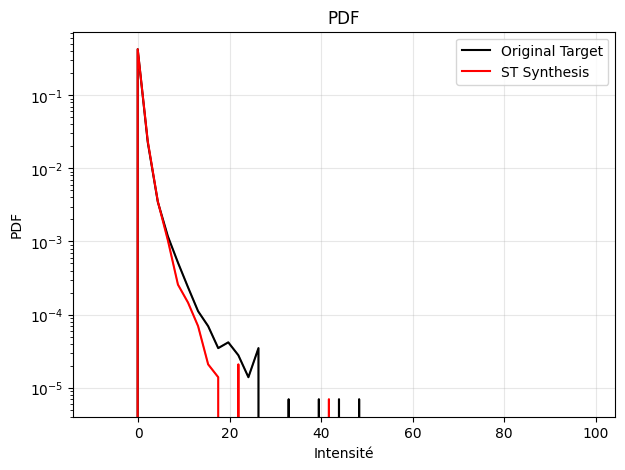

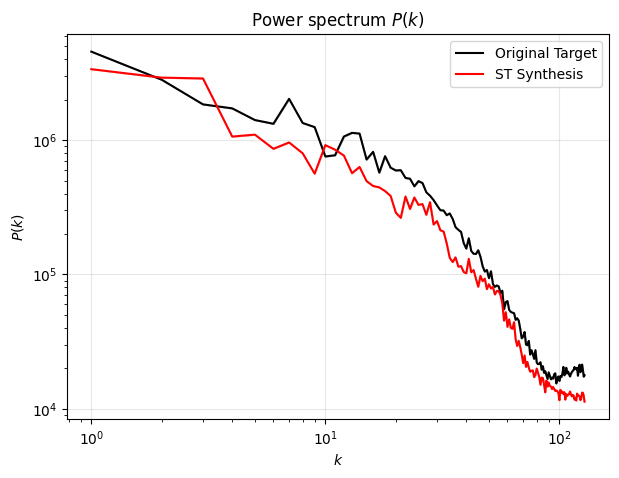

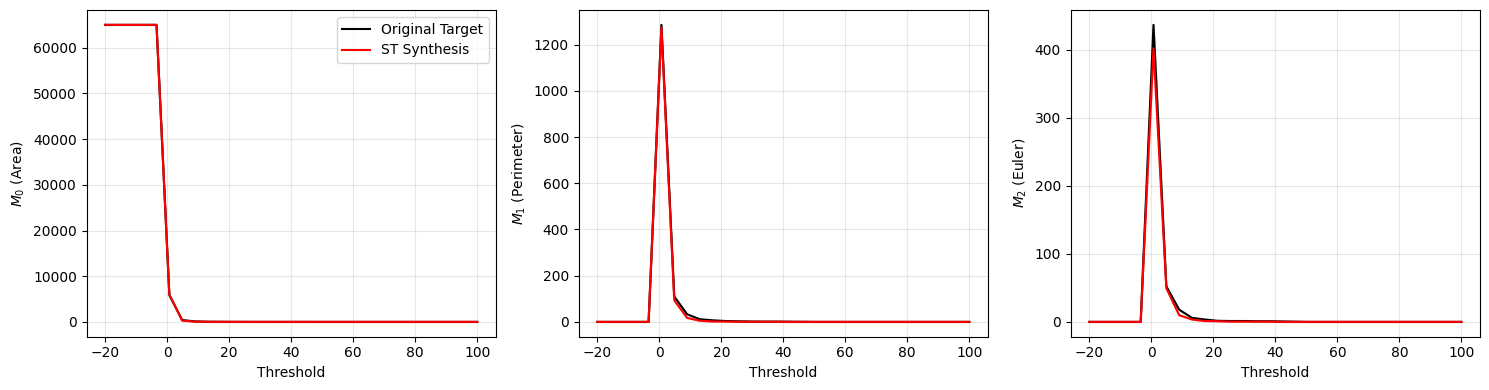

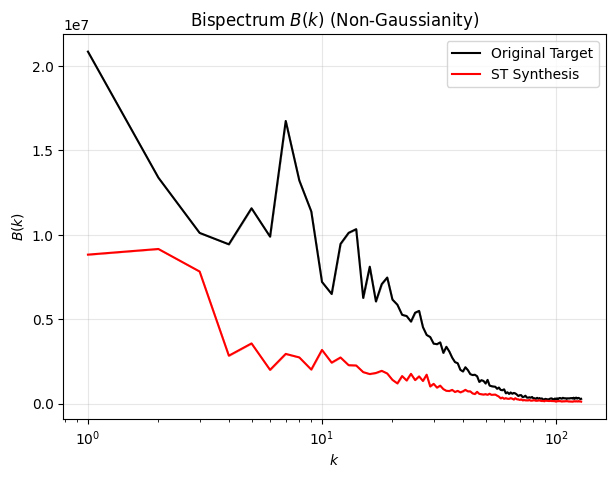

In [19]:
paths = [c['path'] for c in configs]
labels = [c['label'] for c in configs]
colors = [c['color'] for c in configs]

flexible_analysis(
    folders=paths,
    labels=labels,
    colors=colors,
    pdf_range=(-10, 100), 
    mf_range=(-20, 100),
    pdf_bins=50,
    mf_nbins=30
)

# Scoring

In [20]:
from scoring_nonlin_script import *

Load the patches

In [21]:
# Example on the first patch
target_patch = np.load("data/target/patch_0.npy")
synth_patch = np.load("data/synth/synth_0.npy")

Evaluate the loss

In [22]:
loss_val, l_pdf, l_ps = compute_total_loss(target_patch, synth_patch)
print(f"Total loss: {loss_val:.4f} (PDF: {l_pdf:.4f}, PS: {l_ps:.4f})")

Total loss: 0.0539 (PDF: 0.0252, PS: 0.0287)


Details of the loss

In [23]:
# Compute the specific loss
# CDF (from the PDF)
val_pdf = loss_pdf_cdf(target_patch, synth_patch)

# Log of the power spectrum
val_ps = loss_ps_log(target_patch, synth_patch)

# total loss computation
total_score, _, _ = compute_total_loss(target_patch, synth_patch)

print(f"Score : {total_score:.4f}")

Score : 0.0539
